# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [1]:
# Your code goes here
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# Unzip Nasdaq
with zipfile.ZipFile('/content/data_nasdaq_csv.zip') as z:
    z.extractall('/content/nasdaq_data')

# Unzip Vietnam
with zipfile.ZipFile('/content/data-vn-20230228.zip') as z:
    z.extractall('/content/vn_data')

print("Done unzipping")

Done unzipping


Nasdaq folder: /content/nasdaq_data/csv
Example files: ['RDI.csv', 'SKPI.csv', 'PNNT.csv', 'ATOS.csv', 'BIOS.csv']
['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close']
       Open      High       Low     Close     Volume  Adjusted Close
0  0.128348  0.128906  0.128348  0.128348  469033600        0.099874
1  0.122210  0.122210  0.121652  0.121652  175884800        0.094663
2  0.113281  0.113281  0.112723  0.112723  105728000        0.087715
3  0.115513  0.116071  0.115513  0.115513   86441600        0.089886
4  0.118862  0.119420  0.118862  0.118862   73449600        0.092492


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 1.6053e-05 - val_loss: 1.7605e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 5.5807e-07 - val_loss: 2.0600e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5.2209e-07 - val_loss: 1.3724e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5.0438e-07 - val_loss: 1.3877e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.7664e-07 - val_loss: 1.2221e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.5284e-07 - val_loss: 1.1121e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.7305e-07 - val_loss: 1.4570e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.6237e-07 - val_loss: 1.0803e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4.1094e-07 - val_loss: 1.3103e-05
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.7612e-07 - val_loss: 9.5396e-06
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Task 1.1 R

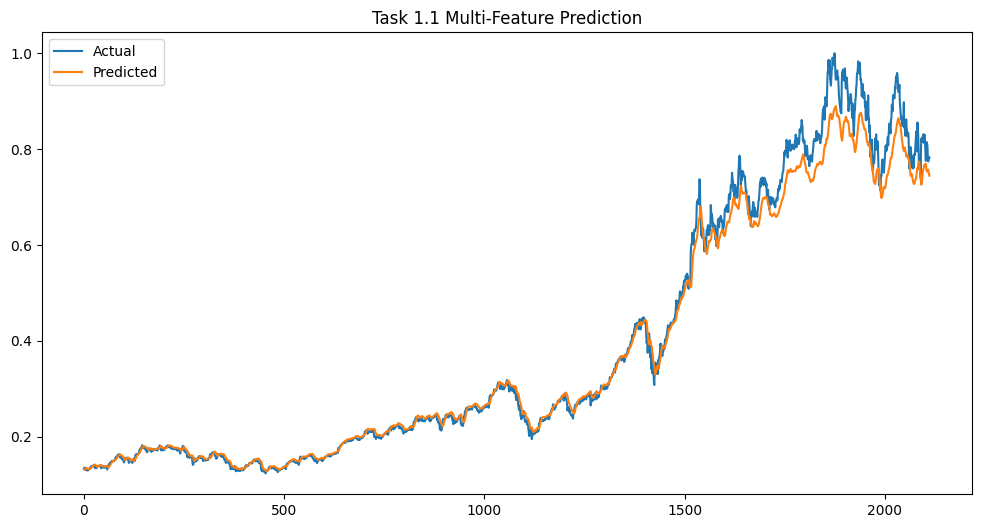

In [3]:
# Task 1.1: Multi-Feature Prediction
# 1. Find Nasdaq CSV folder
for root, dirs, files in os.walk('/content/nasdaq_data'):

    # Ignore __MACOSX folders
    if '__MACOSX' in root:
        continue

    csv_files = [
        f for f in files
        if f.endswith('.csv') and not f.startswith('._')
    ]

    if csv_files:
        nasdaq_folder = root

        print("Nasdaq folder:", nasdaq_folder)
        print("Example files:", csv_files[:5])

        break

# Load AAPL
df = pd.read_csv(os.path.join(nasdaq_folder, 'AAPL.csv'))

# Multi-feature input
features = ['Open', 'High', 'Low', 'Close', 'Volume']

if 'Adj Close' in df.columns:
    features.append('Adj Close')
elif 'Adjusted Close' in df.columns:
    features.append('Adjusted Close')

df = df[features].dropna()

# Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

close_index = features.index('Close')

print(features)
print(df.head())

# Create sequences
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled) - 1):
    X.append(scaled[i - window_size:i])
    y.append(scaled[i + 1][close_index])  # Close price

X = np.array(X)
y = np.array(y)

# Split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Build model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Task 1.1 Results")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Task 1.1 Multi-Feature Prediction')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.4009e-05 - val_loss: 2.9920e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 1.2058e-06 - val_loss: 3.0362e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.3353e-06 - val_loss: 3.0120e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.2304e-06 - val_loss: 4.0536e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.1750e-06 - val_loss: 2.8281e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.0975e-06 - val_loss: 6.9873e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.2444e-06 - val_loss: 2.9154e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.0595e-06 - val_loss: 3.8582e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.0757e-06 - val_loss: 2.6535e-05
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.1226e-06 - val_loss: 2.6430e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Task 1.2 Results - 7t

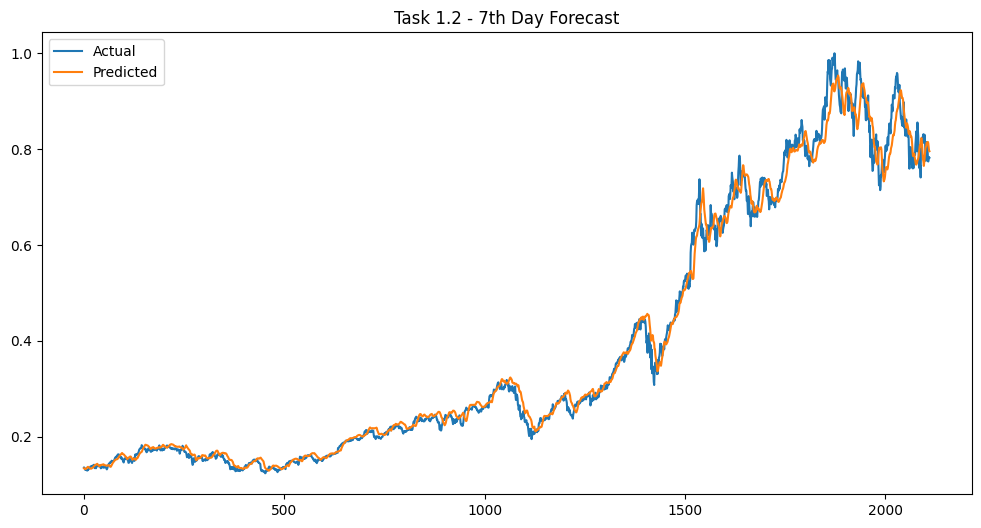

In [4]:
# Task 1.2 - kth-Day Forecast

window_size = 30
k = 7

X = []
y = []

# change len(scaled) - 1 to len(scaled) - k
for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # kth-day future Close price
    y.append(scaled[i + k][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 1.2 Results - {k}th Day Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title(f'Task 1.2 - {k}th Day Forecast')

plt.legend()
plt.show()

X shape: (10553, 30, 6)
y shape: (10553, 7)
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 1.6949e-05 - val_loss: 2.6374e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.1025e-06 - val_loss: 2.3683e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0449e-06 - val_loss: 2.3105e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 9.3234e-07 - val_loss: 2.3001e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 8.6996e-07 - val_loss: 2.1872e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 8.0344e-07 - val_loss: 2.1748e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 8.8853e-07 - val_loss: 2.1917e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 8.1964e-07 - val_loss: 2.0897e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 8.0848e-07 - val_loss: 2.2562e-05
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 7.8563e-07 - val_loss: 2.0370e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Task 1.3 Results - Ne

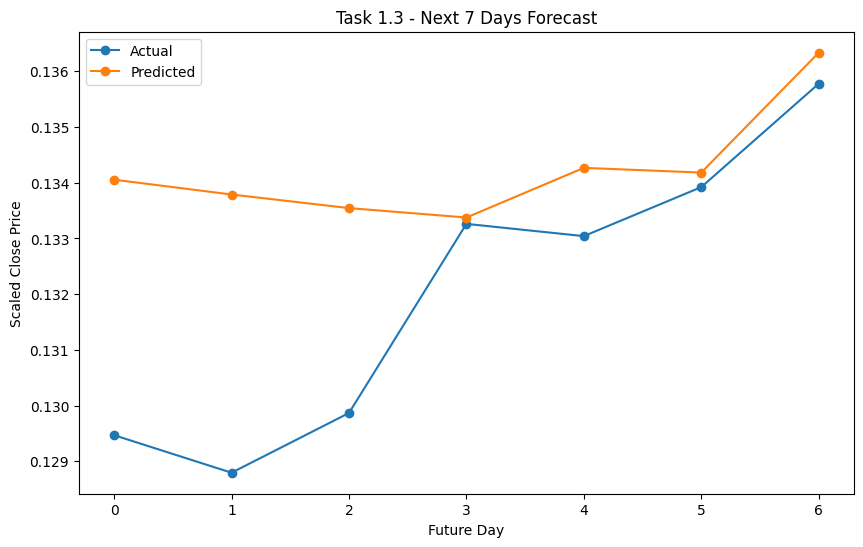

In [5]:
# Task 1.3 - k Days Forecast

window_size = 30
k = 7   # predict next 7 consecutive days

X = []
y = []

for i in range(window_size, len(scaled) - k):

    # past 30 days, all features
    X.append(scaled[i-window_size:i])

    # next k consecutive Close prices
    y.append(scaled[i+1:i+k+1, close_index])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(k)   # output k future days
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 1.3 Results - Next {k} Days Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot first prediction example
plt.figure(figsize=(10,6))

plt.plot(y_test[0], marker='o', label='Actual')
plt.plot(predictions[0], marker='o', label='Predicted')

plt.title(f'Task 1.3 - Next {k} Days Forecast')

plt.xlabel('Future Day')
plt.ylabel('Scaled Close Price')

plt.legend()
plt.show()

Vietnam folder: /content/vn_data/stock-historical-data
Example files: ['TVM-UpcomIndex-History.csv', 'ACB-VNINDEX-History.csv', 'S55-HNXIndex-History.csv', 'VLB-UpcomIndex-History.csv', 'CCI-VNINDEX-History.csv']
   Unnamed: 0     Open     High      Low    Close  Volume TradingDate
0           0  12723.0  12723.0  12723.0  12700.0       0  2015-12-15
1           1  12723.0  12723.0  12723.0  12700.0       0  2015-12-16
2           2  12723.0  12723.0  12723.0  12700.0       0  2015-12-17
3           3  12723.0  12723.0  12723.0  12700.0       0  2015-12-18
4           4  12723.0  12723.0  12723.0  12700.0       0  2015-12-21
Index(['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'TradingDate'], dtype='object')
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0156 - val_loss: 0.0062
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.8129e-04 - val_loss: 0.0061
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.3978e-04 - val_loss: 0.0066
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.2673e-04 - val_loss: 0.0060
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0282e-04 - val_loss: 0.0061
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.7263e-04 - val_loss: 0.0059
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.4662e-04 - val_loss: 0.0059
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.3276e-04 - val_loss: 0.0052
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.3003e-04 - val_loss: 0.0050
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Task 2.1 Results
MAE: 0.032127981383465225
RMSE: 0.06506744341477869


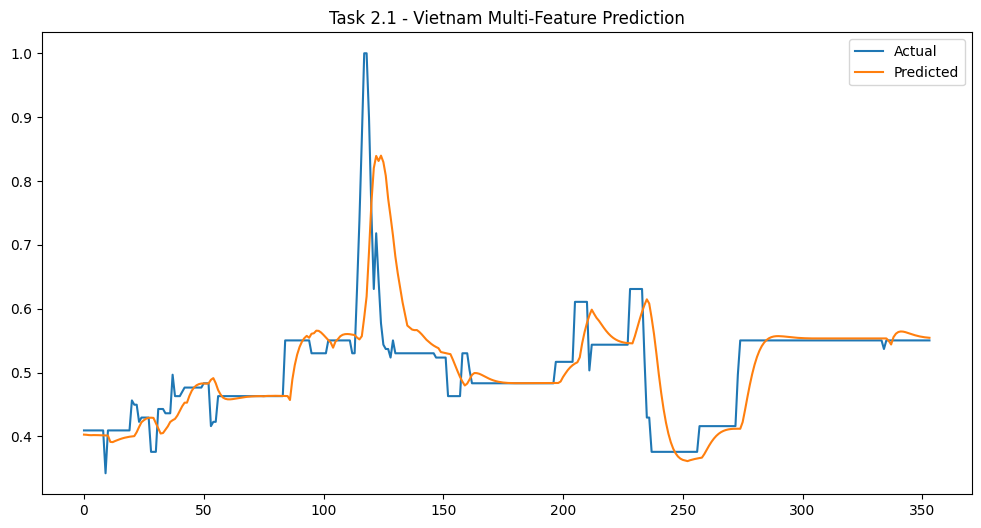

In [6]:
# Task 2.1 - Vietnam Multi-Feature Extension

# Find Vietnam stock csv files
for root, dirs, files in os.walk('/content/vn_data/stock-historical-data'):
    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        vn_folder = root
        print("Vietnam folder:", vn_folder)
        print("Example files:", csv_files[:5])
        break

# Load one Vietnam stock
df = pd.read_csv(os.path.join(vn_folder, csv_files[0]))

print(df.head())
print(df.columns)

# Vietnam multi-feature input
features = ['Open', 'High', 'Low', 'Close', 'Volume']

df = df[features].dropna()

# Scale data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

close_index = features.index('Close')

# Create sequences
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled) - 1):

    X.append(scaled[i-window_size:i])

    # next-day Close price
    y.append(scaled[i + 1][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Task 2.1 Results")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Task 2.1 - Vietnam Multi-Feature Prediction')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0058 - val_loss: 0.0106
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0016 - val_loss: 0.0114
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - val_loss: 0.0113
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 0.0128
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0133
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0014 - val_loss: 0.0141
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014 - val_loss: 0.0154
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0135
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0014 - val_loss: 0.0147
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0155
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Task 2.2 Results - 7th Day Forecast
MAE: 0.0508984908149082
RMSE: 0.08991086232482255


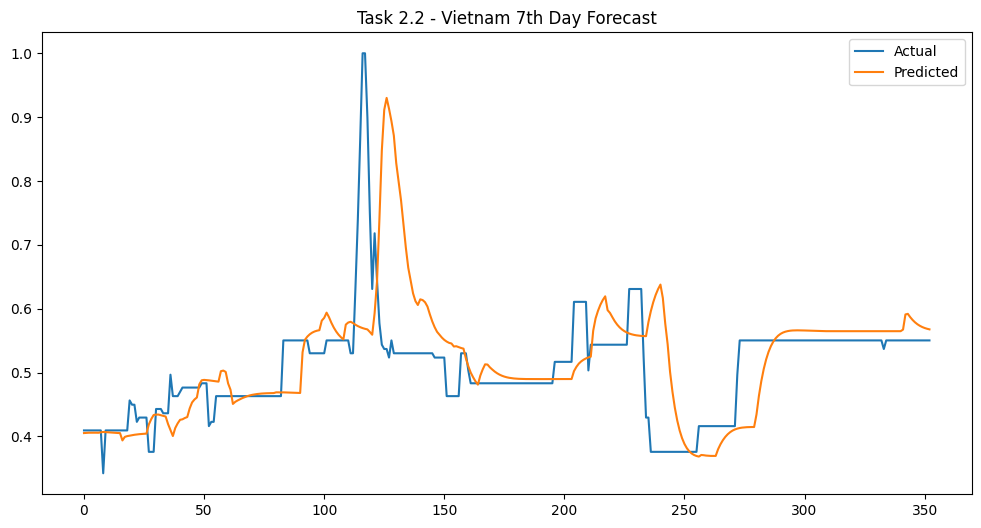

In [7]:
# Task 2.2 - Vietnam kth-day forecast

window_size = 30
k = 7

X = []
y = []

for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # kth-day future Close price
    y.append(scaled[i + k][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 2.2 Results - {k}th Day Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title(f'Task 2.2 - Vietnam {k}th Day Forecast')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0162 - val_loss: 0.0099
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0086
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 0.0083
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 0.0083
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0085
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0088
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0099
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0098
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0110
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0099
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Task 2.3 Results - Next 7 Days Forecast
MAE: 0.04359888132652873
RMSE: 0.07792239149176179


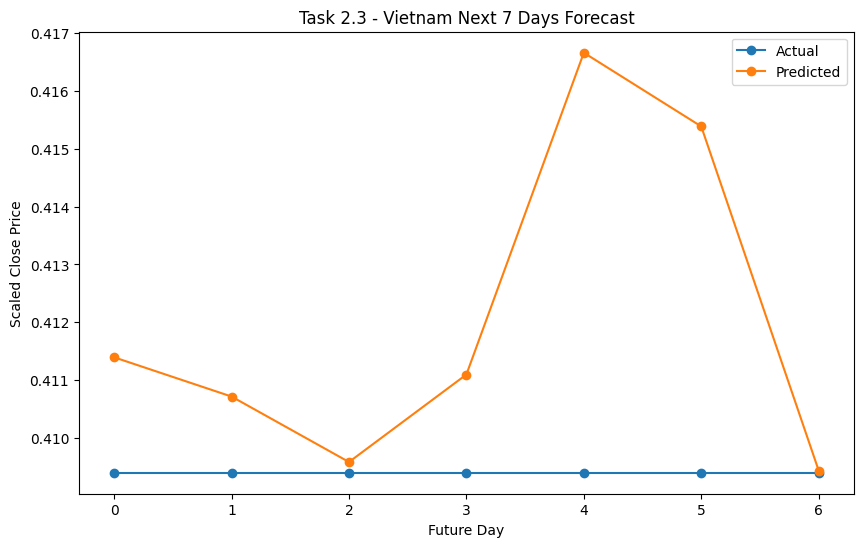

In [8]:
# Task 2.3 - Vietnam k Days Forecast

window_size = 30
k = 7

X = []
y = []

for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # next k consecutive Close prices
    y.append(scaled[i+1:i+k+1, close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    # output k future days
    Dense(k)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 2.3 Results - Next {k} Days Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot first prediction example
plt.figure(figsize=(10,6))

plt.plot(y_test[0], marker='o', label='Actual')
plt.plot(predictions[0], marker='o', label='Predicted')

plt.title(f'Task 2.3 - Vietnam Next {k} Days Forecast')

plt.xlabel('Future Day')
plt.ylabel('Scaled Close Price')

plt.legend()
plt.show()

In [9]:
# Task 3.1 - Buying Signal Identification
window_size = 30
future_window = 7
buy_threshold = 0.05 # 5% increase

close_prices = df['Close'].values

X = []
y = []

for i in range(window_size, len(scaled) - future_window):

    current_close = close_prices[i]

    future_close = close_prices[i + future_window]

    future_return = (
        future_close - current_close
    ) / current_close

    X.append(scaled[i-window_size:i])

    # BUY = 1
    # NOT BUY = 0
    if future_return >= buy_threshold:
        y.append(1)
    else:
        y.append(0)

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Classification model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict probabilities
buy_probabilities = model.predict(X_test)

# Convert probabilities to 0 or 1
buy_predictions = (
    buy_probabilities >= 0.5
).astype(int)

# Metrics
accuracy = accuracy_score(
    y_test,
    buy_predictions
)

precision = precision_score(
    y_test,
    buy_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    buy_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    buy_predictions,
    zero_division=0
)

print("Task 3.1 Results")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9346 - loss: 0.3714 - val_accuracy: 0.8380 - val_loss: 0.5101
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9346 - loss: 0.2403 - val_accuracy: 0.8380 - val_loss: 0.5256
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9346 - loss: 0.2351 - val_accuracy: 0.8380 - val_loss: 0.5054
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9346 - loss: 0.2321 - val_accuracy: 0.8380 - val_loss: 0.5092
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9346 - loss: 0.2327 - val_accuracy: 0.8380 - val_loss: 0.5372
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9346 - loss: 0.2317 - val_accuracy: 0.8380 - val_loss: 0.5220
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9346 - loss: 0.2288 - val_accuracy: 0.8380 - val_loss: 0.5229
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9307 - loss: 0.2351 - val_accuracy: 0.8380 - val_loss: 0.

In [10]:
# Task 3.2 - Selling Signal Identification

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

window_size = 30
future_window = 7

sell_threshold = -0.05   # 5% decrease

close_prices = df['Close'].values

X = []
y = []

for i in range(window_size, len(scaled) - future_window):

    current_close = close_prices[i]

    future_close = close_prices[i + future_window]

    future_return = (
        future_close - current_close
    ) / current_close

    X.append(scaled[i-window_size:i])

    # SELL = 1
    # NOT SELL = 0
    if future_return <= sell_threshold:
        y.append(1)
    else:
        y.append(0)

X = np.array(X)
y = np.array(y)

print("SELL signals:", np.sum(y))
print("NOT SELL signals:", len(y) - np.sum(y))

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Classification model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict probabilities
sell_probabilities = model.predict(X_test)

# Convert probabilities to 0 or 1
sell_predictions = (
    sell_probabilities >= 0.5
).astype(int)

# Metrics
accuracy = accuracy_score(
    y_test,
    sell_predictions
)

precision = precision_score(
    y_test,
    sell_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    sell_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    sell_predictions,
    zero_division=0
)

print("Task 3.2 Results")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

SELL signals: 162
NOT SELL signals: 1602
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9220 - loss: 0.3659 - val_accuracy: 0.8239 - val_loss: 0.6207
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9236 - loss: 0.2711 - val_accuracy: 0.8239 - val_loss: 0.5094
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9236 - loss: 0.2716 - val_accuracy: 0.8239 - val_loss: 0.5182
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9236 - loss: 0.2705 - val_accuracy: 0.8239 - val_loss: 0.5369
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9236 - loss: 0.2719 - val_accuracy: 0.8239 - val_loss: 0.5294
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9236 - loss: 0.2707 - val_accuracy: 0.8239 - val_loss: 0.5221
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9236 - loss: 0.2703 - val_accuracy: 0.8239 - val_loss: 0.5174
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9236 - loss: 0.2703 - val_accuracy: 0.8239 - val_loss: 0.

In [12]:
# Task 4.1 - Profitable stock selection

portfolio_results = []

window_size = 30
k = 7

# Use first 10 stocks to keep runtime reasonable
stock_files = csv_files[:10]

for stock_file in stock_files:

    try:

        temp_df = pd.read_csv(
            os.path.join(vn_folder, stock_file)
        )

        features = ['Open', 'High', 'Low', 'Close', 'Volume']

        # Skip invalid files
        if not all(col in temp_df.columns for col in features):
            continue

        temp_df = temp_df[features].dropna()

        # Skip tiny datasets
        if len(temp_df) < 100:
            continue

        scaler = MinMaxScaler()

        temp_scaled = scaler.fit_transform(temp_df)

        close_index = features.index('Close')

        X = []
        y = []

        for i in range(window_size, len(temp_scaled) - k):

            X.append(temp_scaled[i-window_size:i])

            y.append(temp_scaled[i + k][close_index])

        X = np.array(X)
        y = np.array(y)

        split = int(len(X) * 0.8)

        X_train = X[:split]
        y_train = y[:split]

        # Model
        model = Sequential([
            LSTM(30,
                 input_shape=(X_train.shape[1],
                              X_train.shape[2])),

            Dense(1)
        ])

        model.compile(
            optimizer='adam',
            loss='mse'
        )

        # Shorter training for speed
        model.fit(
            X_train,
            y_train,
            epochs=5,
            batch_size=32,
            verbose=0
        )

        # Predict future
        last_window = temp_scaled[-window_size:]

        last_window = last_window.reshape(
            1,
            window_size,
            len(features)
        )

        predicted_close_scaled = model.predict(last_window, verbose=0)[0][0]

        dummy = np.zeros((1, len(features)))
        dummy[0, close_index] = predicted_close_scaled

        predicted_close_real = scaler.inverse_transform(dummy)[0][close_index]

        current_close_real = temp_df['Close'].iloc[-1]

        expected_return = (predicted_close_real - current_close_real) / current_close_real

        portfolio_results.append({
            'Stock': stock_file,
            'Expected Return': expected_return
        })

    except Exception as e:
        print("Skipped", stock_file, "because:", e)
        continue

# Create dataframe
portfolio_df = pd.DataFrame(portfolio_results)

# Sort best returns first
portfolio_df = portfolio_df.sort_values(
    by='Expected Return',
    ascending=False
)

print("Task 4.1 Results")

print(portfolio_df.head(10))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Task 4.1 Results
                        Stock  Expected Return
5     D2D-VNINDEX-History.csv         0.129601
9     DBC-VNINDEX-History.csv         0.069215
8  TBD-UpcomIndex-History.csv         0.064203
6    VSA-HNXIndex-History.csv         0.060987
7  DAS-UpcomIndex-History.csv         0.023964
0  TVM-UpcomIndex-History.csv         0.014770
3  VLB-UpcomIndex-History.csv        -0.001686
1     ACB-VNINDEX-History.csv        -0.092721
4     CCI-VNINDEX-History.csv        -0.098947
2    S55-HNXIndex-History.csv        -0.212092


In [13]:
# Task 4.2 - Risk Estimation


risks = []

for stock_file in stock_files:

    try:

        temp_df = pd.read_csv(
            os.path.join(vn_folder, stock_file)
        )

        if 'Close' not in temp_df.columns:
            continue

        close_prices = temp_df['Close'].dropna()

        # Daily returns
        returns = close_prices.pct_change().dropna()

        # Volatility = risk
        risk = returns.tail(60).std()

        risks.append({
            'Stock': stock_file,
            'Risk': risk
        })

    except Exception as e:
        print("Skipped", stock_file, "because:", e)

risk_df = pd.DataFrame(risks)

risk_df = risk_df.sort_values(
    by='Risk',
    ascending=False
)

print("Task 4.2 Results")

print(risk_df.head(10))

Task 4.2 Results
                        Stock      Risk
8  TBD-UpcomIndex-History.csv  0.071219
6    VSA-HNXIndex-History.csv  0.045100
3  VLB-UpcomIndex-History.csv  0.039522
2    S55-HNXIndex-History.csv  0.036790
7  DAS-UpcomIndex-History.csv  0.035714
9     DBC-VNINDEX-History.csv  0.035274
4     CCI-VNINDEX-History.csv  0.029143
5     D2D-VNINDEX-History.csv  0.022548
1     ACB-VNINDEX-History.csv  0.019821
0  TVM-UpcomIndex-History.csv  0.003720


Task 4.3 Results
                        Stock  Expected Return      Risk     Score    Weight
0     D2D-VNINDEX-History.csv         0.129601  0.022548  5.747801  0.412497
5  TVM-UpcomIndex-History.csv         0.014770  0.003720  3.970415  0.284941
1     DBC-VNINDEX-History.csv         0.069215  0.035274  1.962230  0.140821
3    VSA-HNXIndex-History.csv         0.060987  0.045100  1.352247  0.097045
2  TBD-UpcomIndex-History.csv         0.064203  0.071219  0.901482  0.064696


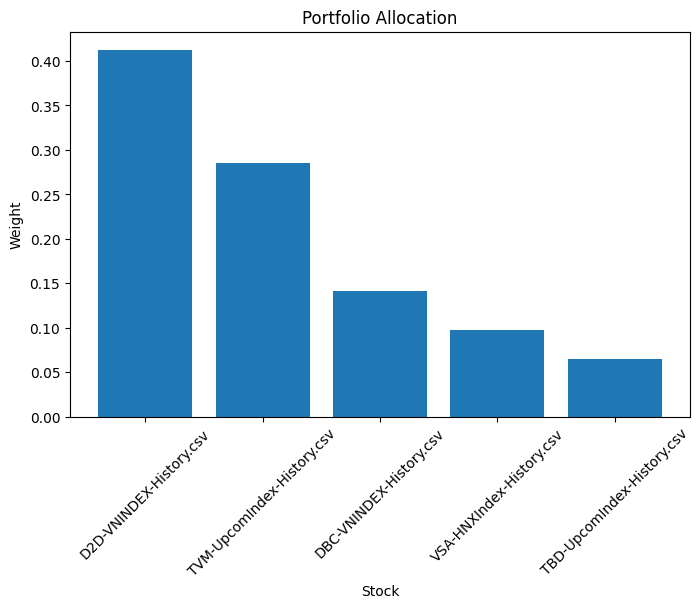

In [14]:
# Task 4.3 - Portfolio Allocation

# Merge return + risk
final_df = pd.merge(
    portfolio_df,
    risk_df,
    on='Stock'
)

# Remove invalid rows
final_df = final_df.replace(
    [np.inf, -np.inf],
    np.nan
)

final_df = final_df.dropna()

# Risk-adjusted score
final_df = final_df[final_df['Risk'] > 0]

final_df['Score'] = (
    final_df['Expected Return']
    / final_df['Risk']
)

# Keep positive-return stocks only
final_df = final_df[
    final_df['Expected Return'] > 0
]

# Best stocks first
final_df = final_df.sort_values(
    by='Score',
    ascending=False
)

# Top 5 portfolio stocks
portfolio = final_df.head(5).copy()

# Normalize weights
portfolio['Weight'] = (
    portfolio['Score']
    / portfolio['Score'].sum()
)

print("Task 4.3 Results")

print(portfolio)

plt.figure(figsize=(8,5))

plt.bar(
    portfolio['Stock'],
    portfolio['Weight']
)

plt.title("Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Weight")

plt.xticks(rotation=45)

plt.show()